Heisenberg S=1/2 Model

L = 10
Sweep 1: E = -4.1511967643
Sweep 2: E = -4.2491637347
Sweep 3: E = -4.2466939289
Sweep 4: E = -4.1700535149
Sweep 5: E = -4.2028319748

L = 20
Sweep 1: E = -8.5725742777
Sweep 2: E = -8.5725245256
Sweep 3: E = -8.5728985504
Sweep 4: E = -8.5727120444
Sweep 5: E = -8.5727051208

L = 30
Sweep 1: E = -13.0013887559
Sweep 2: E = -13.0006883243
Sweep 3: E = -13.0031768996
Sweep 4: E = -13.0025403852
Sweep 5: E = -13.0029431288

L = 40
Sweep 1: E = -17.4315169930
Sweep 2: E = -17.4318946550
Sweep 3: E = -17.4316548825
Sweep 4: E = -17.4321497366
Sweep 5: E = -17.4316677510


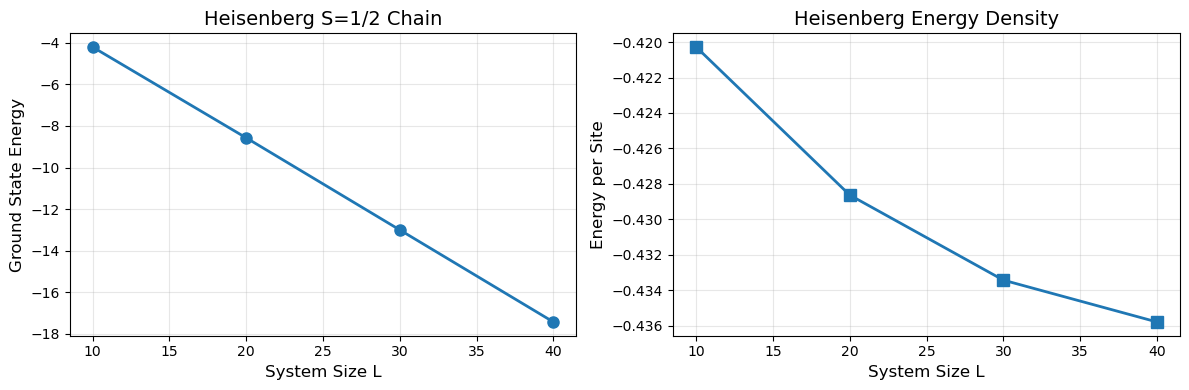


Results saved to figureAKLT/heisenberg_results.png


In [1]:
import numpy as np
from scipy.sparse.linalg import LinearOperator, eigsh
import matplotlib.pyplot as plt
import os

os.makedirs('figureAKLT', exist_ok=True)

# Core functions
def right_canonicalize_qr(M):
    D_left, d, D_right = M.shape
    M_mat = M.reshape(D_left, d * D_right, order='C')
    Q, R = np.linalg.qr(M_mat.T.conj(), mode='reduced')
    return R.T.conj(), Q.T.conj().reshape(-1, d, D_right, order='C')

def right_canonicalize_mps(mps):
    for i in range(len(mps)-1, 0, -1):
        R, B = right_canonicalize_qr(mps[i])
        mps[i] = B
        mps[i-1] = np.einsum('xsa,ab->xsb', mps[i-1], R)
    return mps

def update_left_env(L_old, A, W):
    return np.einsum('bxy,xsa,bBst,ytc->Bac', L_old, A, W, A.conj())

def update_right_env(R_old, B, W):
    return np.einsum('xsa,bBst,Bac,ytc->bxy', B, W, R_old, B.conj())

def build_right_envs(mps, mpo):
    L = len(mps)
    R = [None] * (L + 1)
    R[L] = np.ones((1, 1, 1), dtype=complex)
    for i in range(L-1, 0, -1):
        R[i] = update_right_env(R[i+1], mps[i], mpo[i])
    return R

def apply_two_site_heff(Theta, L, W1, W2, R):
    X = np.einsum('bxy,ystz->bxstz', L, Theta)
    Y = np.einsum('bBsu,bxstz->Bxutz', W1, X)
    Z = np.einsum('BCtv,Bxutz->Cxuvz', W2, Y)
    return np.einsum('Cxuvz,Cza->xuva', Z, R)

def two_site_matvec(v, L, W1, W2, R, Dl, d1, d2, Dr):
    Theta = v.reshape((Dl, d1, d2, Dr), order='C')
    return apply_two_site_heff(Theta, L, W1, W2, R).reshape(Dl * d1 * d2 * Dr, order='C')

# Heisenberg MPO
def build_heisenberg_mpo(L, J=1.0, Jz=1.0, h=0.0):
    Sp = np.array([[0, 1], [0, 0]], dtype=complex)
    Sm = np.array([[0, 0], [1, 0]], dtype=complex)
    Sz = 0.5 * np.array([[1, 0], [0, -1]], dtype=complex)
    I = np.eye(2, dtype=complex)
    chi, d = 5, 2
    mpo = []
    
    W = np.zeros((1, chi, d, d), dtype=complex)
    W[0, 0], W[0, 1], W[0, 2], W[0, 3], W[0, 4] = -h*Sz, 0.5*J*Sm, 0.5*J*Sp, Jz*Sz, I
    mpo.append(W)
    
    for i in range(1, L-1):
        W = np.zeros((chi, chi, d, d), dtype=complex)
        W[0, 0], W[1, 0], W[2, 0], W[3, 0], W[4, 0] = I, Sp, Sm, Sz, -h*Sz
        W[4, 1], W[4, 2], W[4, 3], W[4, 4] = 0.5*J*Sm, 0.5*J*Sp, Jz*Sz, I
        mpo.append(W)
    
    W = np.zeros((chi, 1, d, d), dtype=complex)
    W[0, 0], W[1, 0], W[2, 0], W[3, 0], W[4, 0] = I, Sp, Sm, Sz, -h*Sz
    mpo.append(W)
    return mpo

# Two-site DMRG
def two_site_dmrg(mps, mpo, D_max, n_sweeps=5):
    L = len(mps)
    mps = right_canonicalize_mps(mps)
    R = build_right_envs(mps, mpo)
    L_env = [None] * (L + 1)
    L_env[0] = np.ones((1, 1, 1), dtype=complex)
    energies = []
    
    for sweep in range(n_sweeps):
        for i in range(L-1):
            d1, d2 = mps[i].shape[1], mps[i+1].shape[1]
            Dl, Dr = mps[i].shape[0], mps[i+1].shape[2]
            Theta = np.einsum('xsa,ayb->xsyb', mps[i], mps[i+1])
            Nloc = Dl * d1 * d2 * Dr
            v0 = Theta.reshape(Nloc, order='C')
            
            L_i, W_i, W_ip1, R_ip2 = L_env[i], mpo[i], mpo[i+1], R[i+2]
            def matvec(v):
                return two_site_matvec(v, L_i, W_i, W_ip1, R_ip2, Dl, d1, d2, Dr)
            
            Heff = LinearOperator(shape=(Nloc, Nloc), matvec=matvec, dtype=complex)
            E, vec = eigsh(Heff, k=1, which='SA', v0=v0, tol=1e-8, maxiter=100)
            Theta = vec[:, 0].reshape((Dl, d1, d2, Dr), order='C')
            
            Theta_mat = Theta.reshape(Dl * d1, d2 * Dr, order='C')
            U, S, Vh = np.linalg.svd(Theta_mat, full_matrices=False)
            D_new = min(D_max, len(S))
            U, S, Vh = U[:, :D_new], S[:D_new], Vh[:D_new, :]
            
            mps[i] = U.reshape(Dl, d1, D_new, order='C')
            mps[i+1] = (np.diag(S) @ Vh).reshape(D_new, d2, Dr, order='C')
            if i < L-1:
                L_env[i+1] = update_left_env(L_env[i], mps[i], mpo[i])
        
        for i in range(L-2, -1, -1):
            d1, d2 = mps[i].shape[1], mps[i+1].shape[1]
            Dl, Dr = mps[i].shape[0], mps[i+1].shape[2]
            Theta = np.einsum('xsa,ayb->xsyb', mps[i], mps[i+1])
            Nloc = Dl * d1 * d2 * Dr
            v0 = Theta.reshape(Nloc, order='C')
            
            L_i, W_i, W_ip1, R_ip2 = L_env[i], mpo[i], mpo[i+1], R[i+2]
            def matvec(v):
                return two_site_matvec(v, L_i, W_i, W_ip1, R_ip2, Dl, d1, d2, Dr)
            
            Heff = LinearOperator(shape=(Nloc, Nloc), matvec=matvec, dtype=complex)
            E, vec = eigsh(Heff, k=1, which='SA', v0=v0, tol=1e-8, maxiter=100)
            Theta = vec[:, 0].reshape((Dl, d1, d2, Dr), order='C')
            
            Theta_mat = Theta.reshape(Dl * d1, d2 * Dr, order='C')
            U, S, Vh = np.linalg.svd(Theta_mat, full_matrices=False)
            D_new = min(D_max, len(S))
            U, S, Vh = U[:, :D_new], S[:D_new], Vh[:D_new, :]
            
            mps[i] = (U @ np.diag(S)).reshape(Dl, d1, D_new, order='C')
            mps[i+1] = Vh.reshape(D_new, d2, Dr, order='C')
            if i > 0:
                R[i+1] = update_right_env(R[i+2], mps[i+1], mpo[i+1])
        
        energies.append(E[0].real)
        print(f"Sweep {sweep+1}: E = {E[0].real:.10f}")
    
    return mps, energies

# Run Heisenberg
print("Heisenberg S=1/2 Model")
print("="*50)

L_values = [10, 20, 30, 40]
heisenberg_energies = []

for L in L_values:
    print(f"\nL = {L}")
    mps = [np.random.randn(1 if i==0 else 10, 2, 1 if i==L-1 else 10) + 
           1j*np.random.randn(1 if i==0 else 10, 2, 1 if i==L-1 else 10) 
           for i in range(L)]
    mpo = build_heisenberg_mpo(L)
    mps, energies = two_site_dmrg(mps, mpo, D_max=30, n_sweeps=5)
    heisenberg_energies.append(energies[-1])

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(L_values, heisenberg_energies, 'o-', linewidth=2, markersize=8)
axes[0].set_xlabel('System Size L', fontsize=12)
axes[0].set_ylabel('Ground State Energy', fontsize=12)
axes[0].set_title('Heisenberg S=1/2 Chain', fontsize=14)
axes[0].grid(True, alpha=0.3)

axes[1].plot(L_values, np.array(heisenberg_energies)/np.array(L_values), 's-', linewidth=2, markersize=8)
axes[1].set_xlabel('System Size L', fontsize=12)
axes[1].set_ylabel('Energy per Site', fontsize=12)
axes[1].set_title('Heisenberg Energy Density', fontsize=14)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('figureAKLT/heisenberg_results.png', dpi=150)
plt.show()

print("\n" + "="*50)
print("Results saved to figureAKLT/heisenberg_results.png")
print("="*50)